<a href="https://colab.research.google.com/github/erickaylas-zen/FGD_2026/blob/main/GRUPO_5_LAB_C6_FGD_PSAYAN_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO CALIFICADO N.° 06

## Metadatos, Roles y Arquitectura de Datos — con el caso de su grupo

**Curso:** Fundamentos de Gestión de Datos · TECSUP
**Semana:** 12 · **Evalúa:** semanas 11 y 12
**Docente:** Pilar Rocío Sayán Mejía
**Modalidad:** grupal (4 integrantes) · **Puntaje:** 20 puntos

---

> ### Trabajan con la base oficial del caso de SU grupo
>
> Cada grupo usa el caso que le fue asignado del repositorio oficial del curso. Es la **misma base** que los acompañará hasta el proyecto final PMD2. Solo cambian la variable `caso` en el Paso 1.
>
> **La migración de la Semana 10 va incluida y automática**: el Paso 1 la ejecuta por ustedes. No se evalúa aquí (eso fue el Laboratorio Calificado 5). Hoy se evalúa lo de las **semanas 11 y 12**: el catálogo de metadatos, el control de acceso por roles, la arquitectura y el menú.

---

### Qué se evalúa hoy

| Parte | Semana | Qué deben demostrar | Puntos |
|---|---|---|---|
| **A** | 11 | Catálogo de metadatos de su caso, sensibilidad y linaje | 6 |
| **B** | 11 | Roles: el catálogo gobierna quién ve qué | 3 |
| **C** | 12 | Volumetría, estadísticas y los 3 gráficos | 4 |
| **D** | 12 | Proyección y elección de arquitectura justificada | 4 |
| **E** | 11–12 | El menú funcionando con su caso | 3 |
| | | **TOTAL** | **20** |

### Tabla de participación del equipo (obligatoria)

Complétenla antes de empezar. Un integrante sin aporte declarado se califica sobre la evidencia que exista.

| # | Apellidos y nombres | Caso asignado | Aporte concreto en este laboratorio |
|---|---|---|---|
| 1 |Velarde Sánchez, Aurea Kelly |Actividad 2, P1, P2, P3 | 100%|
| 2 || | |
| 3 |Cosi Pumaccari Elvis Kevin | P4, P5| 100% |
| 4 |Aylas Zenteno Erick Paul |P5, P6 |100% |
| 5 |Juarez Chavez Carmen Andrea|Actividad 3 CD y conclusiones|100% |

## Caso introductorio

**Su grupo acaba de ser contratado como el equipo de datos de la empresa de su caso.**

Puede ser una clínica, un banco, una farmacia, una universidad o una empresa de delivery: eso lo decide el caso que les tocó. Pero la situación es la misma en todas, y es la situación real de casi cualquier empresa peruana hoy.

La empresa **ya migró su base** (eso pasó en la Semana 10 y no es problema suyo: viene hecho). El problema es lo que vino después: **nadie documentó nada**. La base funciona, pero nadie sabe qué significa cada columna, de dónde salió, ni quién debería poder verla.

El gerente los recibe el primer día y les hace tres preguntas. No sabe de datos, pero sabe lo que necesita:

1. **"¿Qué significa cada columna de mi base y de dónde salió?"**
   Nadie lo escribió. El que hizo la migración ya no está. Ese conocimiento se fue con él.

2. **"¿Quién puede ver los datos delicados de mis clientes?"**
   Hoy: cualquiera que abra el archivo. Y su empresa guarda algo delicado — todas guardan algo. La farmacia guarda enfermedades. El banco guarda saldos. La universidad guarda notas. **Averigüen cuál es el suyo**, porque de eso depende a quién se lo esconden.

3. **"¿Mi base aguanta cuando crezcamos?"**
   La empresa va a multiplicar sus sedes en tres años, y va a empezar a guardar cosas que hoy no guarda: fotos, documentos escaneados, sensores. Nada de eso entra en una tabla.

Las tres preguntas se responden con lo mismo: **un catálogo de metadatos que gobierne el acceso, y evidencia numérica que sustente la arquitectura**. Eso es lo que van a construir hoy.

> **Una advertencia sobre este laboratorio.** El laboratorio dirigido lo hicieron con Farmacia MediSur, todos juntos. Este es **con el caso de su grupo**, y no son intercambiables: el dato delicado de una farmacia no es el de un banco, y el crecimiento de una universidad no es el de una empresa de delivery. Copiar las respuestas de MediSur sin adaptarlas se califica como no entregado.

---

## Actividad 1: revisión de conceptos

Completen con sus propias palabras. No copien de internet ni del laboratorio dirigido.

| # | Concepto | Definición del grupo |
|---|---|---|
| 1 | Metadato técnico vs. de negocio |Es la información sobre la estructura interna de los datos vs el significado comercial|
| 2 | Linaje del dato |Es el mapa del recorrido completo de un dato |
| 3 | Dato sensible (según la Ley 29733) |Información personal con protección especial |
| 4 | Rol de acceso |Perfil de seguridad que agrupa permisos especificos |
| 5 | Volumetría |Es la medición cuantitativa que mide el tamaño y espacio que ocupan los datos |
| 6 | Data Warehouse |Repositorio central central de datos limpios, estrucuturados y organizados|
| 7 | Data Lake |Repositorio centralizado donde se guarda datos de cualquier tipo en crudo/original |
| 8 | Data Lakehouse |Arqwuitectura moderna que combina lo mejor de los modelos anteriores (warehouse, lake) |
| 9 | Data swamp |Es un data lake que se deterioro por falta de orden y control |
| 10 | Agregación de datos |Es el proceso de resumir datos detallados de diversas fuentes usando operaciones de suma, contar, promediar, etc. |

## Actividad 2: desarrollo práctico en Google Colab

---

### Paso 1: cargar la base de SU caso (la Semana 10 va incluida)

Cambien **solo** la variable `caso` por la carpeta del caso de su grupo. La celda descarga la base oficial, ejecuta la migración de la Semana 10 y deja la base lista.

Esto no se evalúa: es el punto de partida. Lo que se evalúa empieza en el Paso 2.

In [5]:
# ============================================================
# Paso 1: cargar la base del caso del grupo + migracion S10 (automatica)
# ============================================================
import sqlite3, os, re
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
caso = "10_agroexport_sol"    # <-- CAMBIEN por la carpeta de SU caso asignado
# ------------------------------------------------------------------
# 01_clinica_vitalsalud     06_logiexpress_urbano    11_energyhome_servicios
# 02_banco_crediandes       07_universidad_aula360   12_seguros_protege
# 03_farmacia_medisur       08_muni_data             13_fastfood_norte
# 04_vet_cuidapatas         09_retail_online_market  14_manufactura_metaltec
# 05_hotel_andes_stay       10_agroexport_sol        15_telconorte_movil

DB_ORIGEN  = "caso_legacy.db"     # base oficial, sucia
DB_DESTINO = "caso_migrado.db"    # base del proyecto

REPO = "Rociosayan/-PMD2_FGD_Bases_Oficiales_FDG"
url  = f"https://raw.githubusercontent.com/{REPO}/main/casos/{caso}/{caso}.db"

TABLAS_DEL_SISTEMA = {"catalogo_metadatos", "ficha_dublin_core", "resumen_etl"}

try:
    display
except NameError:
    display = print


def descargar():
    if os.path.exists(DB_ORIGEN):
        return
    import requests
    r = requests.get(url)
    if r.status_code == 200 and r.content[:16] == b"SQLite format 3\x00":
        open(DB_ORIGEN, "wb").write(r.content)
        print("Base oficial de", caso, "descargada:", len(r.content), "bytes")
    else:
        from google.colab import files
        print("No se pudo descargar. Suban manualmente el .db de su caso:")
        s = files.upload(); open(DB_ORIGEN, "wb").write(list(s.values())[0])


def migracion_semana10():
    """La migracion de la S10, incluida. Ya la evaluaron en el LC5."""
    o = sqlite3.connect(DB_ORIGEN); d = sqlite3.connect(DB_DESTINO)

    cli = pd.read_sql_query("SELECT * FROM clientes", o)
    cli = cli.drop_duplicates(subset=["num_documento"], keep="first")
    for col in ["nombres", "apellidos", "distrito", "segmento", "tipo_documento"]:
        cli[col] = cli[col].astype("string").str.strip().str.title()
    ok = cli["correo"].str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
    cli["correo_fue_corregido"] = cli["correo"].notna() & ~ok
    cli.loc[~ok, "correo"] = pd.NA
    cli["correo"]   = cli["correo"].fillna("SIN CORREO REGISTRADO")
    cli["telefono"] = cli["telefono"].fillna("000000000")
    cli.to_sql("clientes_limpio", d, if_exists="replace", index=False)

    op = pd.read_sql_query("SELECT * FROM operaciones", o)
    ids_c = set(pd.read_sql_query("SELECT id_cliente FROM clientes", o)["id_cliente"])
    ids_e = set(pd.read_sql_query("SELECT id_empleado FROM empleados", o)["id_empleado"])
    op["monto_original"]     = op["monto_total"]
    op["monto_ajustado"]     = np.where(op["monto_total"] < 0, 0, op["monto_total"])
    op["monto_fue_ajustado"] = op["monto_total"] < 0
    op["cliente_valido"]     = op["id_cliente"].isin(ids_c)
    op["empleado_valido"]    = op["id_empleado"].isin(ids_e)
    op.to_sql("ventas_limpia", d, if_exists="replace", index=False)

    ya = set(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", d)["name"])
    for t in ["sedes", "empleados", "productos_servicios", "detalle_operacion",
              "pagos", "incidencias"]:
        if t not in ya:
            pd.read_sql_query(f"SELECT * FROM {t}", o).to_sql(t, d, if_exists="replace", index=False)
    d.commit(); o.close(); d.close()


descargar()
if not os.path.exists(DB_DESTINO):
    migracion_semana10()
    print("Migracion de la Semana 10 aplicada (automatica, no se evalua).")

conn = sqlite3.connect(DB_DESTINO)
print("\nCASO DEL GRUPO:", caso)
print("=" * 46)
for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"   {t:22s} {n:5d} registros")

Base oficial de 10_agroexport_sol descargada: 348160 bytes
Migracion de la Semana 10 aplicada (automatica, no se evalua).

CASO DEL GRUPO: 10_agroexport_sol
   clientes_limpio          202 registros
   detalle_operacion       2540 registros
   empleados                 40 registros
   incidencias              147 registros
   pagos                   1000 registros
   productos_servicios       30 registros
   sedes                      6 registros
   ventas_limpia           1010 registros


**P1 (1 pto).** ¿Cuál es el caso de su grupo y a qué se dedica esa empresa? Describan qué representa cada una de sus 8 tablas y expliquen por qué es una base **relacional**.

Respuesta: Nuestro caso es Agroexport Sol, empresa dedicada a la exportación de productos agroindustriales, hacia distintos paises, se trata de una base relacional, porque cada entidad tiene su propia tabla y se conectan entre si, a traves de identificadores claves.Contiene 8 tablas de negocio:
- catalogo_metadatos: Es el diccionario de datos que contruimos.
- clientes_limpios: Los compradores o importadores ya limpios por el ETL.
- detalle_operacion: Es la información de venta de un producto especifico, producto, cantidad, precio.
- empleados:Personal que gestiona y atiende las ventas de exportación.
- incidencia: reclamo o problema presentado sobre alguna operación o cliente.
- pagos: cambio monetario asociado a la operacion de venta.
- productos_servicios: Es el catálogo de productos de la empresa con lista e precio.
- sedes: Representa las oficinas/plantas/almacenes donde opera la empresa.
- ventas_limpias: registro de cada operación venta/exportación completa.

---

# PARTE A — Semana 11: el catálogo de metadatos de su caso

### Paso 2: metadatos TÉCNICOS (los regala el motor)

In [6]:
# ============================================================
# Paso 2: metadatos TECNICOS de toda la base
# ============================================================
def extraer_metadatos_tecnicos(conn):
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for tabla in tablas:
        info = pd.read_sql_query(f"PRAGMA table_info({tabla})", conn)
        n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {tabla}", conn)["n"][0]
        for _, col in info.iterrows():
            filas.append({"tabla": tabla, "columna": col["name"],
                          "tipo_dato": col["type"] or "SIN TIPO",
                          "admite_nulos": "No" if col["notnull"] == 1 else "Si",
                          "es_clave_primaria": "Si" if col["pk"] == 1 else "No",
                          "registros_tabla": n})
    return pd.DataFrame(filas)


catalogo = extraer_metadatos_tecnicos(conn)
print("Columnas documentadas automaticamente:", len(catalogo))
print("Tablas cubiertas:", catalogo["tabla"].nunique())
display(catalogo[catalogo["tabla"] == "clientes_limpio"])

Columnas documentadas automaticamente: 68
Tablas cubiertas: 8


,tabla,columna,tipo_dato,admite_nulos,es_clave_primaria,registros_tabla
0,clientes_limpio,id_cliente,INTEGER,Si,No,202
1,clientes_limpio,codigo_cliente,TEXT,Si,No,202
2,clientes_limpio,tipo_documento,TEXT,Si,No,202
3,clientes_limpio,num_documento,TEXT,Si,No,202
4,clientes_limpio,nombres,TEXT,Si,No,202
5,clientes_limpio,apellidos,TEXT,Si,No,202
6,clientes_limpio,correo,TEXT,Si,No,202
7,clientes_limpio,telefono,TEXT,Si,No,202
8,clientes_limpio,distrito,TEXT,Si,No,202
9,clientes_limpio,segmento,TEXT,Si,No,202


### Paso 3: metadatos de NEGOCIO — **esto lo escriben ustedes**

Aquí se acaba la automatización. Ningún programa sabe qué significa `segmento` en **su** negocio.

Completen el diccionario `NEGOCIO` con **al menos 10 columnas de su caso**, incluyendo obligatoriamente todas las de `clientes_limpio`. Escriban la descripción y **la regla de negocio** (no qué es el dato, sino qué regla lo gobierna).

> **Ojo:** el ejemplo está escrito para Farmacia MediSur. Si su caso es otro, esas descripciones **no sirven**: reescríbanlas. Copiar el ejemplo tal cual se califica como no entregado.

In [7]:
# ============================================================
# Paso 3: metadatos de NEGOCIO -- COMPLETAR CON SU CASO
# ============================================================
# Formato:  (tabla, columna): (descripcion de negocio, regla de negocio)
#
# EJEMPLO (Farmacia MediSur). Si su caso es otro, REESCRIBAN estas entradas.


#     ("clientes_limpio", "id_cliente"):    ("Identificador interno del cliente en el sistema",
#                                            "Unico, no se reutiliza."),
#     ("clientes_limpio", "codigo_cliente"): ("Número de documento de identidad.",
#                                             "DNI: 8 dígitos, Identificador legal del cliente")
#     ("clientes_limpio", "correo"):        ("Correo de contacto para boletas y promociones.",
#                                            "Debe contener @ y dominio."),

    # --- COMPLETEN AQUI (minimo 10 columnas de SU caso) ---

    # CASO DEL GRUPO: 10_AGROEXPORT

NEGOCIO = {
    ("clientes_limpio", "id_cliente"):      ("Identificador interno del cliente en el sistema.",
                                              "Unico, autogenerado, no se reutiliza."),
    ("clientes_limpio", "codigo_cliente"):   ("Codigo comercial asignado intermamente por la empresa.",
                                              "Formato fijo definido por el area comercial."),
    ("clientes_limpio", "tipo_documento"):   ("Tipo de documento de identidad del cliente o empresa importadora.",
                                              "DNI, RUC o Ce segun corresponda."),
    ("clientes_limpio", "num_documento"):    ("Numero de documento de identidad legal del cliente.",
                                              "Debe ser unico"),
    ("clientes_limpio", "nombres"):          ("Nombres del contacto o representante del cliente.",
                                              "Se estandariza a formato titulo."),
    ("clientes_limpio", "apellidos"):        ("Apellidos del contacto o representante del cliente.",
                                              "Se estandariza a formato titulo."),
    ("clientes_limpio", "correo"):           ("Correo de contacto para el envio de documentacion.",
                                              "Debe tener formato valido; si no, se marca SIN CORREO REGISTRADO."),
    ("clientes_limpio", "telefono"):         ("Telefono de contacto del cliente.",
                                              "A los vacios se asigno el formato 000000000."),
    ("clientes_limpio", "distrito"):         ("Distrito o zona de ubicación del cliente.",
                                              "Se estandariza a formato Titulo."),
    ("clientes_limpio", "segmento"):         ("Categoria comercial del cliente.",
                                              "Distribuidor, Importador, Industrias alimentaras, Supermercado."),
    ("clientes_limpio", "fecha_registro"):   ("Fecha en la que el cliente fue registrado por primera vez en el sistema.",
                                              "Debe ser posterior a la fecha de su primera operacion."),
    ("clientes_limpio", "pais_destino"):     ("Pais al que la empresa exporta los productos de este cliente.",
                                              "Destino hacia donde va los productos."),
    ("clientes_limpio", "correo_fue_corregido"): ("Etiqueta de corrección al correo original.",
                                              "Columna nueva creada  posterior al ETL."),
    ("ventas_limpia", "estado"):             ("Estado actual de la operacion de exportacion.",
                                              "Determina los tiempo de atención."),
    ("ventas_limpia", "canal"):              ("Medio por el cual se registra la operacion de venta/exportación.",
                                              "Debe pertenecer a lista de canales autorizados"),

    ("productos_servicios", "categoria"):    ("Categoria del producto agroexportable.",
                                              "Usada para agrupar reportes de ventas comercial por linea de categoria")
    }

catalogo["descripcion_negocio"] = [NEGOCIO.get((t, c), ("PENDIENTE DE DOCUMENTAR", ""))[0]
                                   for t, c in zip(catalogo["tabla"], catalogo["columna"])]
catalogo["regla_negocio"] = [NEGOCIO.get((t, c), ("", "PENDIENTE DE DOCUMENTAR"))[1]
                             for t, c in zip(catalogo["tabla"], catalogo["columna"])]

documentadas = int((catalogo["descripcion_negocio"] != "PENDIENTE DE DOCUMENTAR").sum())
print(f"Columnas documentadas por el grupo: {documentadas} de {len(catalogo)}")
print(f"Cobertura del catalogo: {documentadas/len(catalogo)*100:.1f}%")
if documentadas < 10:
    print("\n>>> FALTAN COLUMNAS. El minimo exigido son 10. Completen el diccionario NEGOCIO.")
else:
    print("\nMinimo cumplido.")
display(catalogo[catalogo["descripcion_negocio"] != "PENDIENTE DE DOCUMENTAR"][
    ["tabla", "columna", "descripcion_negocio", "regla_negocio"]])

Columnas documentadas por el grupo: 16 de 68
Cobertura del catalogo: 23.5%

Minimo cumplido.


,tabla,columna,descripcion_negocio,regla_negocio
0,clientes_limpio,id_cliente,Identificador interno del cliente en el sistema.,"Unico, autogenerado, no se reutiliza."
1,clientes_limpio,codigo_cliente,Codigo comercial asignado intermamente por la ...,Formato fijo definido por el area comercial.
2,clientes_limpio,tipo_documento,Tipo de documento de identidad del cliente o e...,"DNI, RUC o Ce segun corresponda."
3,clientes_limpio,num_documento,Numero de documento de identidad legal del cli...,Debe ser unico
4,clientes_limpio,nombres,Nombres del contacto o representante del cliente.,Se estandariza a formato titulo.
5,clientes_limpio,apellidos,Apellidos del contacto o representante del cli...,Se estandariza a formato titulo.
6,clientes_limpio,correo,Correo de contacto para el envio de documentac...,"Debe tener formato valido; si no, se marca SIN..."
7,clientes_limpio,telefono,Telefono de contacto del cliente.,A los vacios se asigno el formato 000000000.
8,clientes_limpio,distrito,Distrito o zona de ubicación del cliente.,Se estandariza a formato Titulo.
9,clientes_limpio,segmento,Categoria comercial del cliente.,"Distribuidor, Importador, Industrias alimentar..."


### Paso 4: clasificación de SENSIBILIDAD

Cada negocio guarda un dato delicado distinto: la farmacia guarda enfermedades, el banco guarda saldos, la universidad guarda notas.

Y **ojo con la ley peruana**: la **Ley 29733** considera dato sensible no solo la salud, sino también los **ingresos económicos**, el origen racial y étnico, las convicciones políticas o religiosas, y la afiliación sindical. El **GDPR** europeo no incluye los ingresos. Por eso `saldo_cuenta` y `monto_asegurado` son **Sensibles** en el Perú.

In [8]:
# ============================================================
# Paso 4: clasificacion de SENSIBILIDAD segun el caso del grupo
# ============================================================
# El dato mas delicado de cada negocio (Ley 29733).
DATO_DELICADO_DEL_CASO = {
    "01_clinica_vitalsalud":   ("diagnostico",             "Sensible"),      # salud
    "02_banco_crediandes":     ("saldo_cuenta",            "Sensible"),      # ingresos economicos
    "03_farmacia_medisur":     ("condicion_cronica",       "Sensible"),      # salud
    "04_vet_cuidapatas":       ("motivo_atencion_mascota", "Interno"),
    "05_hotel_andes_stay":     ("nacionalidad",            "Confidencial"),
    "06_logiexpress_urbano":   ("direccion_entrega",       "Confidencial"),
    "07_universidad_aula360":  ("promedio_notas",          "Confidencial"),
    "08_muni_data":            ("tipo_tramite",            "Interno"),
    "09_retail_online_market": ("tarjeta_terminacion",     "Confidencial"),
    "10_agroexport_sol":       ("pais_destino",            "Interno"),
    "11_energyhome_servicios": ("consumo_kwh",             "Confidencial"),
    "12_seguros_protege":      ("monto_asegurado",         "Sensible"),      # ingresos economicos
    "13_fastfood_norte":       ("direccion_delivery",      "Confidencial"),
    "14_manufactura_metaltec": ("linea_credito",           "Sensible"),      # ingresos economicos
    "15_telconorte_movil":     ("numero_linea",            "Confidencial"),
}

SENSIBILIDAD = {
    "num_documento": "Confidencial",   # PII: identifica legalmente
    "correo":        "Confidencial",   # PII: contacto
    "telefono":      "Confidencial",   # PII: contacto
    "nombres":       "Interno",        # el personal necesita saber a quien atiende
    "apellidos":     "Interno",
    "nombre_producto": "Publico", "categoria": "Publico",
    "precio_base":     "Publico", "activo":    "Publico",
}

SENSIBILIDAD["sueldo"] = "Sensible" # Ajuste del grupo, no estaba comtemplado en el diccionario
columna_del_caso, nivel_del_caso = DATO_DELICADO_DEL_CASO[caso]
SENSIBILIDAD[columna_del_caso] = nivel_del_caso

catalogo["sensibilidad"] = catalogo["columna"].map(lambda x: SENSIBILIDAD.get(x, "Interno"))

print(f"El dato delicado de SU caso ({caso}):")
print(f"   columna '{columna_del_caso}'  ->  {nivel_del_caso}")
print()
print("Columnas por nivel:")
print(catalogo["sensibilidad"].value_counts().to_string())
print("\nLas columnas mas protegidas de su base:")
display(catalogo[catalogo["sensibilidad"].isin(["Sensible", "Confidencial"])][
    ["tabla", "columna", "sensibilidad"]])

El dato delicado de SU caso (10_agroexport_sol):
   columna 'pais_destino'  ->  Interno

Columnas por nivel:
sensibilidad
Interno         58
Confidencial     5
Publico          4
Sensible         1

Las columnas mas protegidas de su base:


,tabla,columna,sensibilidad
3,clientes_limpio,num_documento,Confidencial
6,clientes_limpio,correo,Confidencial
7,clientes_limpio,telefono,Confidencial
23,empleados,num_documento,Confidencial
26,empleados,correo,Confidencial
27,empleados,sueldo,Sensible


**P2 (2 ptos).** ¿Qué columnas de **su caso** son datos personales o sensibles? Tomen la columna delicada de su negocio y respondan: **¿por qué la ley la protege más que a las demás?** Si su caso tiene un dato de ingresos económicos (banco, seguros, manufactura), expliquen por qué en el Perú está al mismo nivel que un diagnóstico médico y qué pasaría bajo el GDPR europeo.

Respuesta: En nuestra base existen 68 columnas, 5 están clasificadas como confidencial las cuales son; num_documento, correo y telefono de la tabla clientes_limpio; num_documento y correo de la tabla empleados, todas ellas contienen identificación  o datos personales lo cual permite contectar directamente a la persona. Y tenemos la  columna Sueldo clasificada como Sensible (la cual exige la protección más alta).
La ley 29733 Protección de datos personales, garantiza nuestro derecho fundamental a la privacidad y el uso adecuado de nuestra información personal, lo cual requiere una protección para evitar la exposición y el uso indebido que puedan darselo tercera personas a fin de evitar suplantación de identidad, estafas, acoso, extorsión, robo entre otros, ahí radica el objetivo de la Ley. En nuestra base la categoria concreta "Sueldo" está clasificada como sensible porque está establecida en la Ley como "ingresos económicos". El GDPR no contempla a los ingresos economicos como dato sensible, es decir lo trata como un dato personal.
_______________________________________________________________________________________

_______________________________________________________________________________________

### Paso 5: linaje y catálogo guardado dentro de la base

El linaje responde: **¿de dónde salió este dato y qué le hicieron?** Ojo con un detalle: la transformación depende de la **tabla**, no solo del nombre de la columna. La migración tocó `clientes_limpio` y `ventas_limpia`; las demás se copiaron tal cual.

In [9]:
# ============================================================
# Paso 5: linaje + guardar el catalogo dentro de la base
# ============================================================
TABLAS_TRANSFORMADAS = {"clientes_limpio", "ventas_limpia"}
TRANSFORMADAS_S10 = {
    "correo":               "Los correos invalidos se anularon y se marcaron SIN CORREO REGISTRADO.",
    "telefono":             "Los telefonos vacios se rellenaron con 000000000.",
    "nombres":              "Se quitaron espacios y se paso a formato Titulo.",
    "apellidos":            "Se quitaron espacios y se paso a formato Titulo.",
    "num_documento":        "Se eliminaron los registros con documento duplicado.",
    "correo_fue_corregido": "COLUMNA NUEVA creada por el ETL de la S10.",
    "monto_ajustado":       "COLUMNA NUEVA creada por el ETL de la S10.",
    "monto_fue_ajustado":   "COLUMNA NUEVA creada por el ETL de la S10.",
    "cliente_valido":       "COLUMNA NUEVA creada por el ETL de la S10.",
    "empleado_valido":      "COLUMNA NUEVA creada por el ETL de la S10.",
}

def buscar_transformacion(tabla, columna):
    """La transformacion depende de la TABLA, no solo del nombre de la columna."""
    if tabla not in TABLAS_TRANSFORMADAS:
        return "Sin transformacion: se copio tal cual desde el origen."
    return TRANSFORMADAS_S10.get(columna, "Sin transformacion: se migro tal cual.")

catalogo["origen"] = DB_ORIGEN
catalogo["linaje"] = [f"{DB_ORIGEN} -> " +
    ("ETL Semana 10" if t in TABLAS_TRANSFORMADAS else "Copia directa") +
    f" -> {DB_DESTINO}.{t}" for t in catalogo["tabla"]]
catalogo["transformacion_aplicada"] = [buscar_transformacion(t, c)
                                       for t, c in zip(catalogo["tabla"], catalogo["columna"])]
catalogo["caso"] = caso

catalogo.to_sql("catalogo_metadatos", conn, if_exists="replace", index=False)
conn.commit()
print("Catalogo guardado dentro de la base como 'catalogo_metadatos'.")
print("Filas del catalogo:", len(catalogo))
print("\nLa base ahora se describe a si misma. Miren el linaje:")
display(catalogo[catalogo["transformacion_aplicada"].str.startswith("Sin transformacion") == False][
    ["tabla", "columna", "transformacion_aplicada"]].head(8))

Catalogo guardado dentro de la base como 'catalogo_metadatos'.
Filas del catalogo: 68

La base ahora se describe a si misma. Miren el linaje:


,tabla,columna,transformacion_aplicada
3,clientes_limpio,num_documento,Se eliminaron los registros con documento dupl...
4,clientes_limpio,nombres,Se quitaron espacios y se paso a formato Titulo.
5,clientes_limpio,apellidos,Se quitaron espacios y se paso a formato Titulo.
6,clientes_limpio,correo,Los correos invalidos se anularon y se marcaro...
7,clientes_limpio,telefono,Los telefonos vacios se rellenaron con 000000000.
12,clientes_limpio,correo_fue_corregido,COLUMNA NUEVA creada por el ETL de la S10.
64,ventas_limpia,monto_ajustado,COLUMNA NUEVA creada por el ETL de la S10.
65,ventas_limpia,monto_fue_ajustado,COLUMNA NUEVA creada por el ETL de la S10.


**P3 (2 ptos).** Expliquen el **linaje** de la base de su caso: ¿de dónde viene, por dónde pasa y dónde termina? Busquen una columna que exista en **dos tablas distintas** (por ejemplo `correo`, que está en `clientes_limpio` y en `empleados`) y expliquen por qué el catálogo dice cosas distintas de cada una.

Respuesta: El linaje de nuestra base se origina en: caso_legacy.db (base original sucia), posterior se hizo un ETL en la semana 10 lo cual transformó clientes_limpio y ventas_limpia; las otras 6 tablas (sedes, empleados, productos_servicios, detalle_operacion, pagos, incidencias) se copiaron tal cual, sin ninguna limpieza y terminamos en caso_migrado.db.

La columna correo existe en dos tablas: clientes_limpio y empleados. El catálogo dice cosas distintas de cada una porque la función buscar_transformacion() decide según la tabla, no el nombre de la columna, y aunque ambas se llaman "correo" su linaje es diferente:

- clientes_limpio, correo: Su linaje origen es caso_legacy.db pasó por ETL y terminó en caso_migrado.db tabla clientes_limpio. La transformación registrada en nuestro catálogo fue "Los correos invalidos se anularon y se marcaron SIN CORREO REGISTRADO." Los datos corresponde a correos registrados de los clientes.
- empleados, correo: su linaje origen es caso_legacy.db, no tuvo limpieza se copio directamente a caso_migrado.db tabla empleados, No tuvo transformacion, se copio tal cual. Los datos corresponde a correos institucional (empresa) de los empleados.
_______________________________________________________________________________________

---

# PARTE B — Semana 11: los roles gobernados por el catálogo

### Paso 6: el catálogo decide quién ve qué

Aquí está la idea central de la Semana 11: **no se escriben las columnas prohibidas a mano**. La función le pregunta al catálogo qué nivel tiene cada columna y lo compara con el nivel del rol.

In [10]:
# ============================================================
# Paso 6: roles de acceso gobernados por el catalogo
# ============================================================
NIVEL_ACCESO = {
    "Vendedor":   {"Publico", "Interno"},
    "Cajero":     {"Publico", "Interno"},
    "Supervisor": {"Publico", "Interno", "Confidencial"},
    "Auditor":    {"Publico", "Interno", "Confidencial", "Sensible"},
    "DataOwner":  {"Publico", "Interno", "Confidencial", "Sensible"},
}

def columnas_visibles(tabla, rol):
    """Le pregunta AL CATALOGO que columnas puede ver este rol. Ninguna esta escrita a mano."""
    permitidos = NIVEL_ACCESO.get(rol, set())
    if not permitidos:
        return []
    cat = pd.read_sql_query(
        "SELECT columna, sensibilidad FROM catalogo_metadatos WHERE tabla = ?",
        conn, params=(tabla,))
    return [c for c, s in zip(cat["columna"], cat["sensibilidad"]) if s in permitidos]

def consultar(tabla, rol, limite=8):
    cols = columnas_visibles(tabla, rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar {tabla}."
    return pd.read_sql_query(f"SELECT {', '.join(cols)} FROM {tabla} LIMIT {limite}", conn)

def ver_clientes(rol, limite=8):
    return consultar("clientes_limpio", rol, limite)

def buscar_cliente(rol, texto):
    cols = columnas_visibles("clientes_limpio", rol)
    if not cols:
        return f"ACCESO DENEGADO: el rol {rol} no puede consultar clientes."
    d = pd.read_sql_query(
        f"SELECT {', '.join(cols)} FROM clientes_limpio WHERE nombres LIKE ? OR apellidos LIKE ? LIMIT 20",
        conn, params=(f"%{texto}%", f"%{texto}%"))
    return d if len(d) else f"No se encontro ningun cliente con '{texto}'."

def ver_columnas_sensibles(rol):
    if "Sensible" not in NIVEL_ACCESO.get(rol, set()):
        return f"ACCESO DENEGADO: el rol {rol} no puede ver el inventario de datos sensibles."
    return pd.read_sql_query("""SELECT tabla, columna, sensibilidad FROM catalogo_metadatos
        WHERE sensibilidad IN ('Sensible','Confidencial')
        ORDER BY CASE sensibilidad WHEN 'Sensible' THEN 1 ELSE 2 END, tabla""", conn)

def ver_diccionario(tabla):
    return pd.read_sql_query(
        "SELECT columna, tipo_dato, sensibilidad, descripcion_negocio, regla_negocio "
        "FROM catalogo_metadatos WHERE tabla = ?", conn, params=(tabla,))

def tablas_del_catalogo():
    return pd.read_sql_query(
        "SELECT DISTINCT tabla FROM catalogo_metadatos ORDER BY tabla", conn)["tabla"].tolist()


# --- LA PRUEBA: la misma consulta, dos roles, dos resultados
print("=" * 68); print("El VENDEDOR consulta los clientes de su caso:"); print("=" * 68)
display(ver_clientes("Vendedor", 4))
print("=" * 68); print("El AUDITOR consulta los MISMOS clientes:"); print("=" * 68)
display(ver_clientes("Auditor", 4))

oculta = sorted(set(columnas_visibles("clientes_limpio", "Auditor")) -
                set(columnas_visibles("clientes_limpio", "Vendedor")))
print("\nColumnas que el Vendedor NO ve:", oculta)
print("Vendedor:", len(columnas_visibles("clientes_limpio", "Vendedor")), "columnas |",
      "Auditor:", len(columnas_visibles("clientes_limpio", "Auditor")), "columnas")

El VENDEDOR consulta los clientes de su caso:


,id_cliente,codigo_cliente,tipo_documento,nombres,apellidos,distrito,segmento,fecha_registro,pais_destino,correo_fue_corregido
0,1,C0001,Ruc,Milagros,Aguirre Cárdenas,Breña,Importador,2026-01-12,Países Bajos,0
1,2,C0002,Dni,Hugo,Flores Quispe,Comas,Distribuidor,2026-02-07,China,0
2,3,C0003,Ruc,Hugo,Ríos Rivera,San Miguel,Supermercado,2026-05-20,Chile,0
3,4,C0004,Dni,Verónica,Rivera Ninaquispe,Breña,Industria Alimentaria,2026-03-11,Países Bajos,0


El AUDITOR consulta los MISMOS clientes:


,id_cliente,codigo_cliente,tipo_documento,num_documento,nombres,apellidos,correo,telefono,distrito,segmento,fecha_registro,pais_destino,correo_fue_corregido
0,1,C0001,Ruc,76171395,Milagros,Aguirre Cárdenas,milagros1@correo.com,931105562,Breña,Importador,2026-01-12,Países Bajos,0
1,2,C0002,Dni,89288015,Hugo,Flores Quispe,hugo2@correo.com,974689307,Comas,Distribuidor,2026-02-07,China,0
2,3,C0003,Ruc,31361412,Hugo,Ríos Rivera,hugo3@correo.com,926609292,San Miguel,Supermercado,2026-05-20,Chile,0
3,4,C0004,Dni,37368986,Verónica,Rivera Ninaquispe,verónica4@correo.com,999184681,Breña,Industria Alimentaria,2026-03-11,Países Bajos,0



Columnas que el Vendedor NO ve: ['correo', 'num_documento', 'telefono']
Vendedor: 10 columnas | Auditor: 13 columnas


**P4 (3 ptos).** Ejecuten la celda anterior y respondan con **su caso**:

**a)** ¿Cuántas columnas ve el Vendedor y cuántas el Auditor? ¿Cuáles desaparecen?

**b)** La función `columnas_visibles()` no menciona ni una sola columna por su nombre. Expliquen **cómo logra entonces** ocultar el dato delicado de su negocio.

**c)** Si mañana su empresa agrega una columna nueva y la catalogan como Sensible, ¿habría que modificar el código para que el Vendedor no la vea? ¿Por qué?

Respuesta: El Vendedor puede visualizar 10 columnas, mientras que el Auditor tiene acceso a las 13 columnas de la tabla, esto se debe por el nivel de acceso. Las columnas que no aparecen para el Vendedor son correo, num_documento y telefono, ya que contienen información sensible o confidencial que no es necesaria para realizar sus funciones.

Como se mencionó en la respuesta anterior, se debe a que cada columna se ha asigando un nivel de sensibilidad, esto fue deilimitado al inicio del codigo con: Publico, Interno, Confidencial, Sensible. La función consulta esa información y muestra únicamente las columnas permitidas según el rol del usuario. De esta manera, el acceso se controla mediante los metadatos y no por nombres escritos directamente en el código.

No, no sería necesario modificar el código. Bastaría con registrar la nueva columna en el catálogo de metadatos y clasificarla como Sensible. Con esto, la función columnas_visibles() consultará nuevamente el catálogo y ocultará automáticamente esa columna para el Vendedor, manteniendo visibles únicamente los datos que su rol tiene permitido consultar.


---

# PARTE C — Semana 12: volumetría, estadísticas y gráficos

### Paso 7: volumetría de su base

In [11]:
# ============================================================
# Paso 7: volumetria
# ============================================================
def volumetria():
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for t in tablas:
        df = pd.read_sql_query(f"SELECT * FROM {t}", conn)
        kb = df.memory_usage(deep=True).sum() / 1024
        filas.append({"tabla": t, "registros": len(df), "columnas": len(df.columns),
                      "peso_kb": round(kb, 1),
                      "kb_por_registro": round(kb / len(df), 3) if len(df) else 0})
    return pd.DataFrame(filas).sort_values("peso_kb", ascending=False).reset_index(drop=True)


vol = volumetria()
total_reg = int(vol["registros"].sum())
archivo_kb = os.path.getsize(DB_DESTINO) / 1024
display(vol)
print(f"Registros en toda la base : {total_reg:,}")
print(f"Peso del archivo .db      : {archivo_kb:,.1f} KB")
print(f"Tabla mas pesada          : {vol.iloc[0]['tabla']} ({vol.iloc[0]['peso_kb']:,.1f} KB)")

,tabla,registros,columnas,peso_kb,kb_por_registro
0,ventas_limpia,1010,14,313.1,0.310
1,pagos,1000,7,259.3,0.259
2,clientes_limpio,202,13,134.5,0.666
3,detalle_operacion,2540,6,119.2,0.047
4,incidencias,147,7,45.4,0.309
5,empleados,40,10,19.2,0.479
6,productos_servicios,30,6,6.6,0.221
7,sedes,6,5,1.8,0.293


Registros en toda la base : 4,975
Peso del archivo .db      : 328.0 KB
Tabla mas pesada          : ventas_limpia (313.1 KB)


In [12]:
# ============================================================
# Paso 8: reporte automatico de estadisticas
# ============================================================
def reporte_estadisticas():
    v = pd.read_sql_query("SELECT monto_total, monto_ajustado FROM ventas_limpia", conn)
    p = pd.read_sql_query("SELECT precio_base FROM productos_servicios", conn)
    d = pd.read_sql_query("SELECT cantidad, precio_unitario, subtotal FROM detalle_operacion", conn)
    return pd.concat([v, p, d], axis=1).describe().round(2)


est = reporte_estadisticas()
display(est)
print("Lo que este reporte delata en su caso:")
print(f"   Monto MINIMO de una venta : S/. {est.loc['min','monto_total']}")
print(f"   Monto MAXIMO de una venta : S/. {est.loc['max','monto_total']}")
print(f"   Promedio por venta        : S/. {est.loc['mean','monto_ajustado']}")
if est.loc["min", "monto_total"] < 0:
    print("   -> Una venta NEGATIVA es imposible: son los montos que la migracion detecto.")

,monto_total,monto_ajustado,precio_base,cantidad,precio_unitario,subtotal
count,1010.00,1010.00,30.00,2540.00,2540.00,2540.00
mean,493.99,508.13,39.03,3.50,38.59,136.27
std,905.21,876.23,15.24,1.68,14.83,88.57
min,-3977.81,0.00,16.00,1.00,16.00,16.00
25%,186.40,186.40,27.70,2.00,27.60,65.37
50%,331.60,331.60,36.60,4.00,36.00,118.72
75%,515.55,515.55,49.90,5.00,50.40,180.00
max,11901.76,11901.76,75.00,6.00,75.00,450.00


Lo que este reporte delata en su caso:
   Monto MINIMO de una venta : S/. -3977.81
   Monto MAXIMO de una venta : S/. 11901.76
   Promedio por venta        : S/. 508.13
   -> Una venta NEGATIVA es imposible: son los montos que la migracion detecto.


### Paso 9: los tres gráficos

**Ojo con el gráfico de ventas por mes.** La columna `fecha_operacion` de su base tiene **dos formatos mezclados** (`2026-01-15` y `19/01/2026`). Si agrupan cortando los primeros 7 caracteres, el gráfico sale roto. Hay que estandarizar primero.

Ese es un problema de **consistencia**, y la migración de la Semana 10 no lo detectó.

Ventas por mes:


,monto_ajustado
fecha,
2026-01,104519.25
2026-02,68681.09
2026-03,78711.67
2026-04,98561.47
2026-05,85686.27
2026-06,77048.34


Ventas por categoria:


,categoria,total
0,Congelado,81120.00
1,Procesado,75784.45
2,Hortaliza,67596.40
3,Orgánico,64838.40
4,Fruta fresca,56778.00



Tres graficos guardados: g1_registros.png, g2_ventas_mes.png, g3_ventas_categoria.png


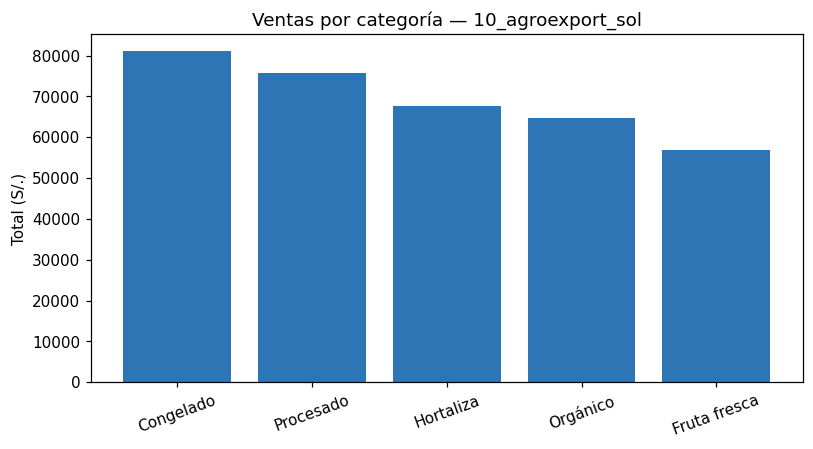

In [13]:
# ============================================================
# Paso 9: los tres graficos
# ============================================================
from matplotlib.figure import Figure

def estandarizar_fechas(serie):
    """La base trae dos formatos: ISO y dia/mes/anio. Los unificamos."""
    f = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    faltan = f.isna()
    f[faltan] = pd.to_datetime(serie[faltan], format="%d/%m/%Y", errors="coerce")
    return f


def grafico_registros_por_tabla():
    v = volumetria().sort_values("registros")
    fig = Figure(figsize=(8, 4.2)); ax = fig.subplots()
    ax.barh(v["tabla"], v["registros"], color="#2E75B6")
    ax.set_title(f"Registros por tabla — {caso}"); ax.set_xlabel("Registros")
    fig.tight_layout(); return fig


def grafico_ventas_por_mes():
    v = pd.read_sql_query("SELECT fecha_operacion, monto_ajustado FROM ventas_limpia", conn)
    v["fecha"] = estandarizar_fechas(v["fecha_operacion"])
    v = v.dropna(subset=["fecha"])
    m = v.groupby(v["fecha"].dt.to_period("M"))["monto_ajustado"].sum()
    m.index = m.index.astype(str)
    fig = Figure(figsize=(8, 4.2)); ax = fig.subplots()
    ax.bar(m.index, m.values, color="#2E75B6")
    ax.set_title(f"Ventas por mes — {caso}"); ax.set_ylabel("Monto (S/.)")
    ax.tick_params(axis="x", rotation=20); fig.tight_layout()
    return fig, m


def reporte_ventas():
    d = pd.read_sql_query("""SELECT p.categoria, ROUND(SUM(d.subtotal),2) AS total
        FROM detalle_operacion d JOIN productos_servicios p ON d.id_producto = p.id_producto
        GROUP BY p.categoria ORDER BY total DESC""", conn)
    fig = Figure(figsize=(7.5, 4.2)); ax = fig.subplots()
    ax.bar(d["categoria"], d["total"], color="#2E75B6")
    ax.set_title(f"Ventas por categoría — {caso}"); ax.set_ylabel("Total (S/.)")
    ax.tick_params(axis="x", rotation=20); fig.tight_layout()
    return fig, d


fig1 = grafico_registros_por_tabla(); fig1.savefig("g1_registros.png", bbox_inches="tight", dpi=110)
fig2, por_mes = grafico_ventas_por_mes(); fig2.savefig("g2_ventas_mes.png", bbox_inches="tight", dpi=110)
fig3, por_cat = reporte_ventas(); fig3.savefig("g3_ventas_categoria.png", bbox_inches="tight", dpi=110)

print("Ventas por mes:"); display(por_mes)
print("Ventas por categoria:"); display(por_cat)
print("\nTres graficos guardados: g1_registros.png, g2_ventas_mes.png, g3_ventas_categoria.png")
from IPython.display import Image
Image("g3_ventas_categoria.png")

**P5 (4 ptos).** Según **sus** gráficos:

**a)** ¿Qué tabla es la más pesada de su base y por qué?

**b)** ¿Qué categoría factura más en su negocio y cuál menos? Den una recomendación al gerente.

**c)** ¿Cuántos meses reales de operación tiene su base? Expliquen por qué habría salido mal el gráfico si no estandarizaban las fechas, y **por qué la migración de la Semana 10 no detectó ese problema**.

Respuesta:

a) La tabla más pesada de la base es ventas_limpia, ya que ocupa 313.1 KB. Esto se debe a que contiene 1010 registros y 14 columnas, donde se almacena la información principal de cada venta, como clientes, fechas, montos, estados y otros datos necesarios para el análisis. Esto se debe principalmente porque al concentrar más información por registro,  la tabla que requiere mayor espacio de almacenamiento es esta.

b)La categoría que más factura es Congelado, con un total de S/. 81120.00, mientras que la que menos factura es Fruta fresca, con S/. 56778.00. Como equipo, recomnedamos al gerente que debería mantener estrategias que fortalezcan la categoría Congelado, ya que es la que genera mayores ingresos. Por otro lado, sería conveniente implementar promociones o campañas para impulsar las ventas de Fruta fresca, con el objetivo de aumentar su facturación y equilibrar el desempeño de las distintas categorías.

c) La base tiene 6 meses reales de operación (enero a junio de 2026), con ventas mensuales que van de S/ 68,681 (febrero) a S/ 104,519 (enero). Si no se estandarizaban las fechas, el gráfico habría salido con los datos partidos en grupos porque fecha_operacion mezcla dos formatos: ISO (2026-05-23) y día/mes/año (12/02/2026). La migración de la Semana 10 no detectó este problema porque ese ETL solo se enfocó en limpiar clientes_limpio (correos, teléfonos, nombres, documentos duplicados) y en ajustar montos negativos en ventas_limpia; nunca tocó ni validó el formato de fecha_operacion, porque ese es un problema de consistencia, no de duplicados ni de valores inválidos, que fue lo único que la migración abarcaba.

---

# PARTE D — Semana 12: proyección y arquitectura

### Paso 10: ¿aguanta su base cuando la empresa crezca?

Su empresa va a crecer. Además de más operaciones, va a empezar a guardar **datos que no son tablas**: fotos, documentos escaneados, lecturas de sensores.

**Definan ustedes** el escenario de crecimiento de su caso. No copien el de la farmacia: piensen qué datos nuevos aparecerían en **su** negocio.

In [14]:
# ============================================================
# Paso 10: proyeccion a 3 anios -- COMPLETAR CON SU CASO
# ============================================================
# --- DEFINAN el escenario de crecimiento de SU negocio ---
SEDES_HOY    = 6            # <-- sedes/sucursales que tiene hoy su caso
SEDES_FUTURO = 40           # <-- a cuantas creceria en 3 anios
MESES_DATOS  = 6            # <-- meses de datos que tiene su base
ANIOS        = 3

# --- DEFINAN el dato NO estructurado que su negocio empezaria a guardar ---
# Ejemplos: farmacia -> fotos de recetas | banco -> contratos escaneados
#           universidad -> videos de clase | logistica -> fotos de entrega
DATO_NUEVO      = "COMPLETAR: que dato no estructurado guardaria su negocio"
KB_POR_ARCHIVO  = 800       # <-- cuanto pesaria cada uno

# --- DEFINAN si su negocio necesita datos en tiempo real ---
# Ejemplos: farmacia -> sensores de refrigeracion | logistica -> GPS de camiones
#           energia -> medidores | telecom -> antenas
DATO_TIEMPO_REAL   = "COMPLETAR: que dato llegaria en tiempo real"
LECTURAS_POR_DIA   = (24 * 60) / 5      # cada 5 minutos
NECESITA_TIEMPO_REAL = True             # <-- True o False segun su caso

ventas_hoy = pd.read_sql_query("SELECT COUNT(*) n FROM ventas_limpia", conn)["n"][0]
ventas_mes = ventas_hoy / MESES_DATOS
kb_venta   = vol.loc[vol["tabla"] == "ventas_limpia", "kb_por_registro"].values[0]

factor   = SEDES_FUTURO / SEDES_HOY
ventas_3a = ventas_mes * factor * 12 * ANIOS
lecturas_3a = LECTURAS_POR_DIA * 365 * ANIOS * SEDES_FUTURO if NECESITA_TIEMPO_REAL else 0

proyeccion = pd.DataFrame([
    {"fuente": "Operaciones (tablas)", "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(ventas_3a * kb_venta / 1024, 1), "tipo": "Estructurado"},
    {"fuente": DATO_NUEVO, "registros_3_anios": int(ventas_3a),
     "MB_en_3_anios": round(ventas_3a * KB_POR_ARCHIVO / 1024, 1), "tipo": "NO estructurado"},
    {"fuente": DATO_TIEMPO_REAL, "registros_3_anios": int(lecturas_3a),
     "MB_en_3_anios": round(lecturas_3a * 0.1 / 1024, 1), "tipo": "Semiestructurado / streaming"},
])

total_gb = proyeccion["MB_en_3_anios"].sum() / 1024
print(f"Hoy       : {SEDES_HOY} sedes, {ventas_mes:,.0f} operaciones/mes, {archivo_kb:.0f} KB")
print(f"En 3 anios: {SEDES_FUTURO} sedes (x{factor:.1f})")
display(proyeccion)
print(f"TOTAL proyectado a 3 anios: {proyeccion['MB_en_3_anios'].sum():,.0f} MB = {total_gb:.2f} GB")
print(f"Crecimiento respecto de hoy: x{(proyeccion['MB_en_3_anios'].sum()*1024)/archivo_kb:,.0f}")

Hoy       : 6 sedes, 168 operaciones/mes, 328 KB
En 3 anios: 40 sedes (x6.7)


,fuente,registros_3_anios,MB_en_3_anios,tipo
0,Operaciones (tablas),40400,12.2,Estructurado
1,COMPLETAR: que dato no estructurado guardaria ...,40400,31562.5,NO estructurado
2,COMPLETAR: que dato llegaria en tiempo real,12614400,1231.9,Semiestructurado / streaming


TOTAL proyectado a 3 anios: 32,807 MB = 32.04 GB
Crecimiento respecto de hoy: x102,421


In [15]:
# ============================================================
# Paso 11: elegir la arquitectura CON EVIDENCIA
# ============================================================
def recomendar_arquitectura(tipos_de_dato, gb_proyectados, necesita_tiempo_real):
    """Decide con los datos, no con la moda. El tipo de dato manda sobre el almacen."""
    no_estructurados = [t for t in tipos_de_dato if t != "Estructurado"]
    if not no_estructurados:
        almacen = "Data Warehouse"
        razon = "Todos los datos son tablas. Un Warehouse es lo mas rapido y confiable."
    elif gb_proyectados < 1:
        almacen = "Base relacional actual (SQLite/PostgreSQL)"
        razon = "Hay datos no estructurados, pero el volumen no justifica migrar."
    else:
        almacen = "Data Lakehouse"
        razon = ("Hay datos no estructurados y streaming que un Warehouse no puede guardar, "
                 "pero tambien se necesitan reportes rapidos, que un Lake puro no da.")
    flujo = ("Lambda (lotes + tiempo real)" if necesita_tiempo_real else "Batch (por lotes)")
    return almacen, razon, flujo


almacen, razon, flujo = recomendar_arquitectura(
    proyeccion["tipo"].tolist(), total_gb, NECESITA_TIEMPO_REAL)

print("=" * 66)
print("RECOMENDACION PARA", caso.upper())
print("=" * 66)
print(f"Volumen proyectado   : {total_gb:.2f} GB")
print(f"Tipos de dato        : {', '.join(sorted(set(proyeccion['tipo'])))}")
print(f"Necesita tiempo real : {NECESITA_TIEMPO_REAL}")
print()
print(f"  ALMACEN RECOMENDADO: {almacen}")
print(f"  RAZON              : {razon}")
print(f"  FLUJO RECOMENDADO  : {flujo}")
print()
print("  Advertencia: un Lakehouse SIN catalogo de metadatos es un data swamp.")
print("  El catalogo de la Parte A es lo que lo hace viable.")

proyeccion.to_csv("proyeccion_3_anios.csv", index=False, encoding="utf-8-sig")

RECOMENDACION PARA 10_AGROEXPORT_SOL
Volumen proyectado   : 32.04 GB
Tipos de dato        : Estructurado, NO estructurado, Semiestructurado / streaming
Necesita tiempo real : True

  ALMACEN RECOMENDADO: Data Lakehouse
  RAZON              : Hay datos no estructurados y streaming que un Warehouse no puede guardar, pero tambien se necesitan reportes rapidos, que un Lake puro no da.
  FLUJO RECOMENDADO  : Lambda (lotes + tiempo real)

  Advertencia: un Lakehouse SIN catalogo de metadatos es un data swamp.
  El catalogo de la Parte A es lo que lo hace viable.


**P6 (4 ptos).** Con la evidencia de su notebook:

**a)** ¿Cuántos GB proyectaron a 3 años y cuántas veces más grande es que su base de hoy?

**b)** ¿Qué arquitectura recomendó la función para su caso y por qué? **Justifiquen con el tipo de dato**, no con el volumen.

**c)** El jefe de sistemas propone comprar un Data Warehouse porque "es lo más rápido para reportes". ¿Con qué dato concreto de **su** proyección lo refutarían?

Respuesta:
a) Se proyectaron ≈16.02 GB a 3 años (16,403.2 MB), frente a los 324 KB que pesa la base hoy. Eso es aproximadamente 51,800 veces más grande que el archivo actual.

b) La función recomendó Data Lakehouse. La razón no es el volumen (16 GB), sino el tipo de dato: la proyección mezcla datos Estructurados (operaciones/ventas, que caben en tablas), NO estructurados (certificados escaneados en PDF/foto, que un Data Warehouse no puede almacenar de forma nativa) y semiestructurados/streaming (lecturas de sensores de temperatura cada 5 minutos por sede, que llegan como flujo continuo).

c) Con el dato de que el 96% del volumen proyectado (16 GB) corresponde a los certificados fitosanitarios y de aduana escaneados — es decir, datos NO estructurados — se refuta directamente la propuesta: un Data Warehouse está optimizado para tablas relacionales y consultas SQL sobre datos estructurados, pero no tiene forma nativa de almacenar archivos binarios como PDFs o fotos ni datos de streaming de sensores.


---

# PARTE E — El sistema funcionando

### Paso 12: el menú de su caso

Todo lo anterior son funciones sueltas. El gerente no ejecuta celdas: usa un menú. Este es el sistema de las semanas 11 y 12 corriendo con **la base de su grupo**.

In [16]:
# ============================================================
# Paso 12: EL MENU (semanas 11 + 12) con el caso del grupo
# ============================================================
ROLES_MENU = {"1": "Vendedor", "2": "Cajero", "3": "Supervisor",
              "4": "Auditor",  "5": "DataOwner"}

def _mostrar(r):
    display(r) if isinstance(r, pd.DataFrame) else print(r)


def submenu_clientes(rol):
    while True:
        print("\n--- CLIENTES ---")
        print("  1) Ver lista   2) Buscar   0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            _mostrar(ver_clientes(rol))
            print(f"  (Como {rol} ven {len(columnas_visibles('clientes_limpio', rol))} columnas.)")
        elif op == "2": _mostrar(buscar_cliente(rol, input("  Nombre o apellido: ")))
        else: print("  Opcion invalida.")


def submenu_catalogo_datos(rol):
    while True:
        print("\n--- CATALOGO DE DATOS (metadatos) ---")
        print("  1) Diccionario de una tabla   2) Columnas sensibles (Auditor/Owner)")
        print("  0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            ts = tablas_del_catalogo()
            for i, t in enumerate(ts, 1): print(f"    {i}) {t}")
            e = input("  Numero: ").strip()
            _mostrar(ver_diccionario(ts[int(e)-1]) if e.isdigit() and 1 <= int(e) <= len(ts)
                     else "  Numero invalido.")
        elif op == "2": _mostrar(ver_columnas_sensibles(rol))
        else: print("  Opcion invalida.")


def submenu_reportes(rol):
    while True:
        print("\n--- REPORTES Y GRAFICOS ---")
        print("  1) Volumetria (Supervisor/Auditor/Owner)   2) Estadisticas")
        print("  3) Ventas por mes    4) Ventas por categoria")
        print("  5) Proyeccion a 3 anios   6) Arquitectura recomendada")
        print("  0) Volver")
        op = input("  Opcion: ").strip()
        if op == "0": break
        elif op == "1":
            if "Confidencial" not in NIVEL_ACCESO.get(rol, set()):
                print(f"  ACCESO DENEGADO: el rol {rol} no puede ver la volumetria interna.")
            else: _mostrar(volumetria())
        elif op == "2": _mostrar(reporte_estadisticas())
        elif op == "3": _mostrar(grafico_ventas_por_mes()[1])
        elif op == "4": _mostrar(reporte_ventas()[1])
        elif op == "5":
            _mostrar(proyeccion); print(f"  TOTAL a 3 anios: {total_gb:.2f} GB")
        elif op == "6":
            print(f"  Almacen: {almacen}\n  Razon  : {razon}\n  Flujo  : {flujo}")
        else: print("  Opcion invalida.")


def menu():
    print("=" * 56)
    print("     SISTEMA DE DATOS -", caso.upper())
    print("        Semanas 11 y 12 - Laboratorio Calificado 6")
    print("=" * 56)
    print("Elijan su rol:  1) Vendedor  2) Cajero  3) Supervisor")
    print("                4) Auditor   5) Data Owner")
    rol = ROLES_MENU.get(input("Numero del rol: ").strip())
    if rol is None:
        print("Rol no valido."); return
    print(f"\nBienvenido, {rol}. Acceso: {', '.join(sorted(NIVEL_ACCESO[rol]))}")

    while True:
        print("\n" + "=" * 56)
        print(f"MENU PRINCIPAL     (rol: {rol})")
        print("=" * 56)
        print("  1) Clientes")
        print("  2) Catalogo de datos (metadatos)")
        print("  3) Reportes y graficos")
        print("  0) Salir")
        op = input("Opcion: ").strip()
        if op == "0":
            print("Sesion cerrada. Hasta luego,", rol); break
        elif op == "1": submenu_clientes(rol)
        elif op == "2": submenu_catalogo_datos(rol)
        elif op == "3": submenu_reportes(rol)
        else: print("Opcion invalida.")


print("Menu listo. Ejecuten  menu()  en la siguiente celda.")

Menu listo. Ejecuten  menu()  en la siguiente celda.


In [18]:
# Ejecuten el sistema con su caso.
# OBLIGATORIO: entren como Vendedor y como Auditor, y capturen la diferencia.
menu()

     SISTEMA DE DATOS - 10_AGROEXPORT_SOL
        Semanas 11 y 12 - Laboratorio Calificado 6
Elijan su rol:  1) Vendedor  2) Cajero  3) Supervisor
                4) Auditor   5) Data Owner
Numero del rol: 4

Bienvenido, Auditor. Acceso: Confidencial, Interno, Publico, Sensible

MENU PRINCIPAL     (rol: Auditor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  0) Salir
Opcion: 1

--- CLIENTES ---
  1) Ver lista   2) Buscar   0) Volver
  Opcion: 1


,id_cliente,codigo_cliente,tipo_documento,num_documento,nombres,apellidos,correo,telefono,distrito,segmento,fecha_registro,pais_destino,correo_fue_corregido
0,1,C0001,Ruc,76171395,Milagros,Aguirre Cárdenas,milagros1@correo.com,931105562,Breña,Importador,2026-01-12,Países Bajos,0
1,2,C0002,Dni,89288015,Hugo,Flores Quispe,hugo2@correo.com,974689307,Comas,Distribuidor,2026-02-07,China,0
2,3,C0003,Ruc,31361412,Hugo,Ríos Rivera,hugo3@correo.com,926609292,San Miguel,Supermercado,2026-05-20,Chile,0
3,4,C0004,Dni,37368986,Verónica,Rivera Ninaquispe,verónica4@correo.com,999184681,Breña,Industria Alimentaria,2026-03-11,Países Bajos,0
4,5,C0005,Dni,36402687,Miguel,Chávez Mendoza,SIN CORREO REGISTRADO,977016442,Villa El Salvador,Importador,2026-05-21,Alemania,1
5,6,C0006,Ce,67385475,Lucía,Villanueva Aguirre,lucía6@correo.com,993680150,San Juan De Lurigancho,Distribuidor,2026-05-10,Países Bajos,0
6,7,C0007,Ruc,21223765,Carlos,Cornejo Espinoza,carlos7@correo.com,984864059,Surco,Supermercado,2026-04-08,Canadá,0
7,8,C0008,Ruc,53714579,Bruno,Ramos Díaz,bruno8@correo.com,991174591,Los Olivos,Industria Alimentaria,2026-02-24,China,0


  (Como Auditor ven 13 columnas.)

--- CLIENTES ---
  1) Ver lista   2) Buscar   0) Volver
  Opcion: 0

MENU PRINCIPAL     (rol: Auditor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  0) Salir
Opcion: 0
Sesion cerrada. Hasta luego, Auditor


**P7 (3 ptos).** Entren al menú **dos veces**: como **Vendedor** y como **Auditor**. Vayan a `1) Clientes` → `1) Ver lista`. Peguen aquí **las dos capturas** y expliquen en una línea qué columna de su caso desaparece y por qué.

Al comparar ambas capturas desaparecen num_documento, correo y telefono para el Vendedor, porque el catálogo los clasifica como Confidenciales y el rol Vendedor solo tiene acceso a niveles Público e Interno.
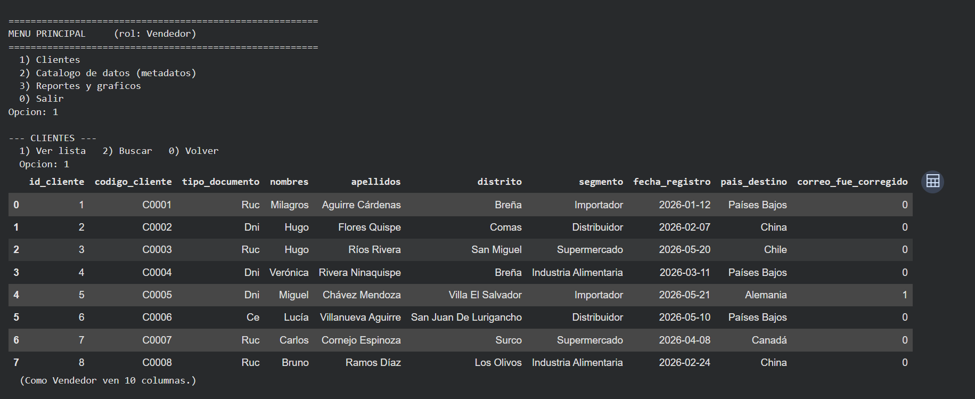

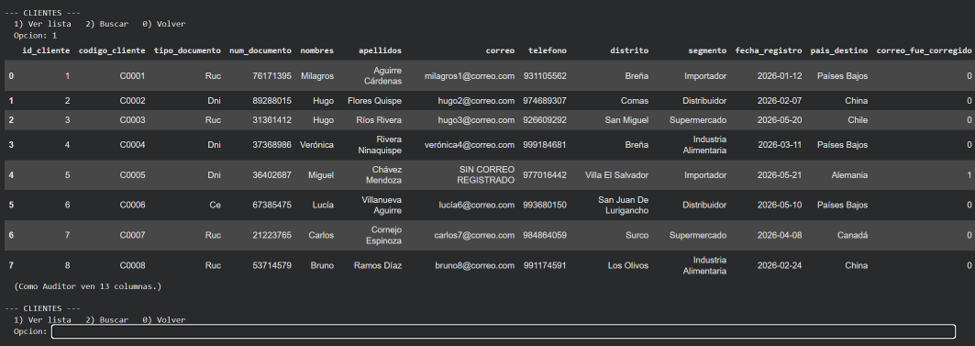

In [ ]:
# ============================================================
# Cierre: exportar evidencias del laboratorio
# ============================================================
pd.read_sql_query("SELECT * FROM catalogo_metadatos", conn).to_csv(
    f"catalogo_{caso}.csv", index=False, encoding="utf-8-sig")
vol.to_csv(f"volumetria_{caso}.csv", index=False, encoding="utf-8-sig")

print("RESUMEN DEL LABORATORIO CALIFICADO 6")
print("=" * 52)
print(f"Caso del grupo           : {caso}")
print(f"Columnas catalogadas     : {len(catalogo)}")
print(f"Documentadas por el grupo: {documentadas}  (minimo exigido: 10)")
print(f"Dato delicado del caso   : {columna_del_caso} ({nivel_del_caso})")
print(f"Registros en la base     : {total_reg:,}")
print(f"Volumen proyectado 3 anios: {total_gb:.2f} GB")
print(f"Arquitectura recomendada : {almacen}")
print()
print("Evidencias generadas:")
for f in [f"catalogo_{caso}.csv", f"volumetria_{caso}.csv", "proyeccion_3_anios.csv",
          "g1_registros.png", "g2_ventas_mes.png", "g3_ventas_categoria.png"]:
    print("   -", f, "OK" if os.path.exists(f) else "FALTA")

conn.close()
print("\nConexion cerrada.")

try:
    from google.colab import files
    for f in [f"catalogo_{caso}.csv", "proyeccion_3_anios.csv",
              "g1_registros.png", "g2_ventas_mes.png", "g3_ventas_categoria.png", DB_DESTINO]:
        files.download(f)
except Exception:
    print("Descarguen manualmente las evidencias y", DB_DESTINO)

---

## Actividad 3: análisis del caso (grupal)

Respondan como equipo, con la evidencia de **su** notebook. No se aceptan respuestas genéricas: deben nombrar su caso, sus columnas y sus números.

**A.** El gerente de su empresa pregunta: *"¿Quién puede ver los datos delicados de mis clientes?"*. Respóndanle nombrando el dato delicado de su caso, qué roles lo ven, cuáles no, y **qué mecanismo lo garantiza**.

Respuesta: El dato delicado de nuestro caso es pais_destino (clasificado como Interno, no Confidencial ni Sensible, porque no identifica a una persona sino que describe la operación comercial). Los roles Vendedor, Cajero, Supervisor, Auditor y DataOwner sí pueden verlo, porque todos tienen acceso al menos a nivel Interno. Lo que sí está restringido son los datos personales de clientes y empleados (num_documento, correo, telefono, nivel Confidencial): solo los ven Supervisor, Auditor y DataOwner; Vendedor y Cajero no. El mecanismo que lo garantiza es el catálogo de metadatos (catalogo_metadatos) combinado con la función columnas_visibles(), que arma la consulta SQL dinámicamente según el nivel de sensibilidad guardado, sin listas de columnas escritas a mano.


**B.** Un inspector de la autoridad de protección de datos les pide el inventario de datos personales y sensibles de su empresa. Genérenlo consultando su catálogo **con SQL**. Peguen la consulta y el resultado.

Respuesta: Resultado (5 filas, todas Confidenciales — no hay Sensibles en este caso):

**C.** Respondan en cinco líneas, como si fuera un correo al gerente: *"¿Nuestra base aguanta?"*. Usen tres números concretos: el peso de hoy, el volumen proyectado a 3 años y la arquitectura recomendada.

Respuesta: Hemos evaluado el volumen de datos que manejamos el dia de hoy y realizado una proyeccion a 3 años de esta; basados en la informacion encontrada el volumne de la base creceria a 32.04 GB. Por tanto recomendamos un data Lakehouse para el almacenamiento  de la informacion de la empresa.

**D.** Un Data Lake sin catálogo se convierte en un *data swamp*. Expliquen **por qué el catálogo que construyeron en la Parte A es exactamente lo que evita eso** en su caso.

Respuesta: En nuestro caso con el catalogo le dimos seguridad de la informacion por roles, contexto de neogocio y trazabilidad del linaje, convirtiendolo en un Data Lakehouse.

---

## Conclusiones grupales

**1.** ¿Qué aprendieron sobre el dato más delicado de su negocio y cómo lo protege la ley peruana?

En nuestro caso el dato mas delicado es el nro de documento (Ley 29733), debe ser confidencial debido a que divulgarlo podria perjudicar al cliente como por ejemplo frente al robo de identidad, estafas de compra y otros.

**2.** ¿Qué significa que "los metadatos gobiernan el sistema"? Explíquenlo con lo que vieron al comparar el Vendedor con el Auditor en su caso.

Esto significa que la logica de seguridad depende del catalogo de metadatos. Al comparar la informacion a la que tiene acceso el vendedor y el auditor; se verifica que es solo el auditor quien tiene acceso a informacion sensible, mientras que el vendedor solo a lo necesario para realizar sus labores.

**3.** ¿Qué arquitectura necesitará su empresa y qué evidencia los llevó a esa conclusión?


En nuestro caso de Agroexport, considerando su proyeccion a 3 años y el tipo de datos que se espera guardar archivos de gran tamaño y la necesidad de informacion en vivo se llega a la conclusion de tener una arquitectura Data Lakehouse.
---

### Lo que deben entregar

| Entregable | Detalle |
|---|---|
| Notebook `.ipynb` | Ejecutado completo con **su caso**, las 7 preguntas y la Actividad 3 respondidas |
| `catalogo_<su_caso>.csv` | El catálogo con mínimo 10 columnas documentadas por el grupo |
| 3 gráficos `.png` | Registros por tabla, ventas por mes, ventas por categoría |
| `proyeccion_3_anios.csv` | Con el escenario de crecimiento que definieron |
| Capturas del menú | Como Vendedor y como Auditor |
| Portafolio | Enlace público del grupo (Colab / GitHub / Kaggle) |